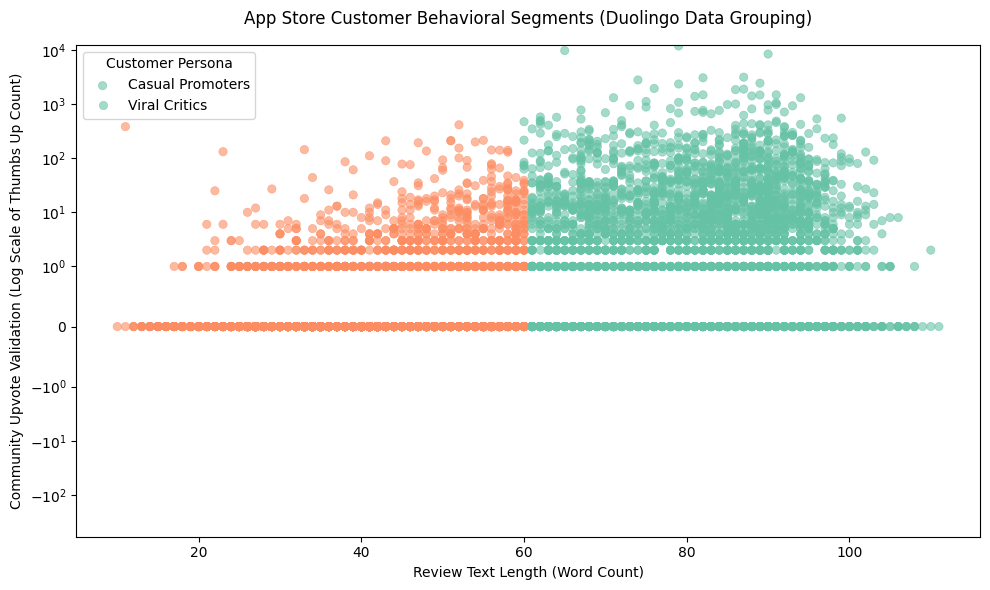

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load your engineered production dataset
df = pd.read_csv('../data/cleaned_duolingo.csv')

# 2. Select the behavioral dimensions for clustering
cluster_features = ['review_length', 'thumbsUpCount']
X_cluster = df[cluster_features]

# 3. Scale features to equalize vector weights during K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 4. Run K-Means Clustering (K=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['user_segment'] = kmeans.fit_predict(X_scaled)

# 5. Plot with correct axis scaling to reveal data points
plt.figure(figsize=(10, 6))

# Clear any previous plot configurations in notebook memory
plt.clf() 

# Create the scatter plot using your clean data
sns.scatterplot(
    x='review_length', 
    y='thumbsUpCount', 
    hue='user_segment', 
    data=df, 
    palette='Set2', 
    alpha=0.6,
    edgecolor=None
)

# CRITICAL FIX: Use log scale on Y-axis to reveal compressed points
plt.yscale('symlog', linthresh=1)

# Add clear, descriptive labels for your academic report
plt.title('App Store Customer Behavioral Segments (Duolingo Data Grouping)', fontsize=12, pad=15)
plt.xlabel('Review Text Length (Word Count)', fontsize=10)
plt.ylabel('Community Upvote Validation (Log Scale of Thumbs Up Count)', fontsize=10)

# Rename the legend categories to fit your user personas
plt.legend(title='Customer Persona', labels=['Casual Promoters', 'Viral Critics'])

plt.tight_layout()
plt.savefig('customer_segments.png', dpi=300)
plt.show()